# Get measured capacity and resistance for each formation protocol

2025/04/30

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from scipy.interpolate import interp1d

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'


    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'


    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'


    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'


    return file_arbin_list, daq_channel


In [3]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2])

    file_arbin_list, daq_channel = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.nan

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out, df_arbin


# Load the experimental data

In [4]:
expt1, df1 = fetch_experimental_data(152064)
expt2, df2 = fetch_experimental_data(152074)
expt3, df3 = fetch_experimental_data(152071)
expt4, df4 = fetch_experimental_data(152098)

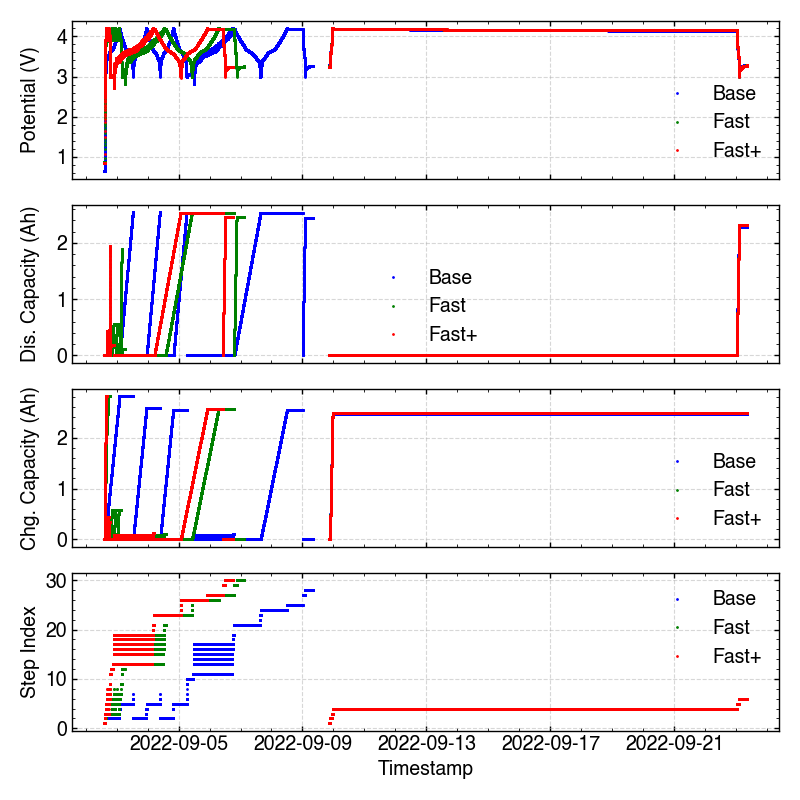

In [30]:
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()



In [6]:
# Define the step indices for the HPPC sequence
si1_hppc = [11, 12, 13, 14, 15, 16, 17]
si2_hppc = [13, 14, 15, 16, 17, 18, 19]
si3_hppc = [13, 14, 15, 16, 17, 18, 19]


In [7]:
# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
subset_df1 = df1[df1['Step Index'].isin(si1_hppc)]
subset_df3 = df3[df3['Step Index'].isin(si2_hppc)]
subset_df4 = df4[df4['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_24772/1429211087.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_24772/1429211087.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T

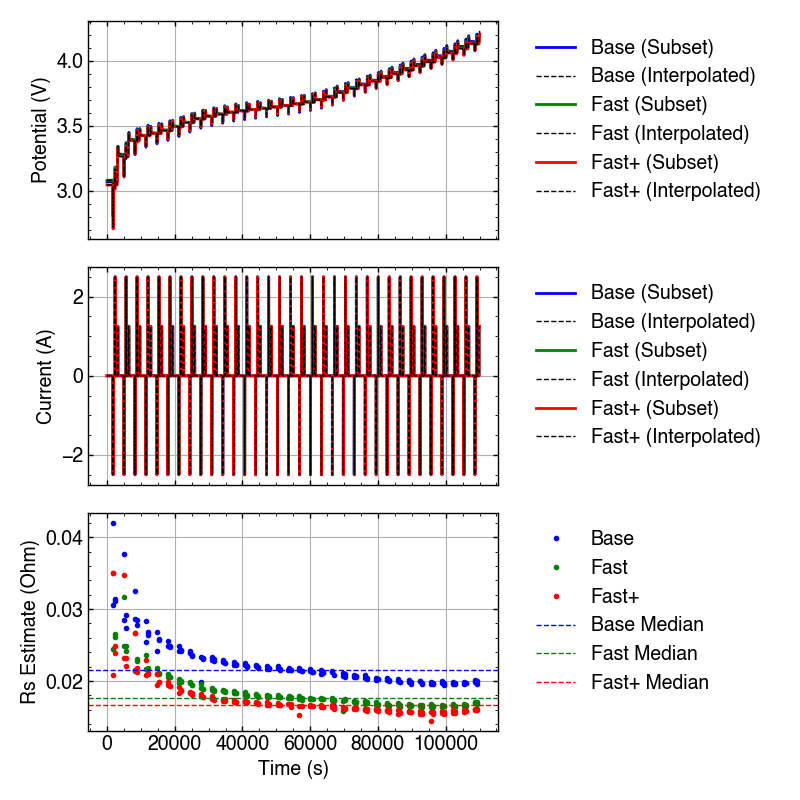

In [17]:
def calculate_resistance_estimates(Vmeas, Imeas):

    den = - (Imeas[0:-2] - Imeas[1:-1])
    num = Vmeas[1:-1] - Vmeas[0:-2]
    idx = np.where(np.abs(den) > 1.5)[0]
    Rs_estimate = num[idx]/den[idx]

    return Rs_estimate, idx

Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axs[0].plot(subset_df1['Time (s)'], subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)'], subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)'], subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)'], subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)'], subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)'], subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axs[2].plot(subset_df1['Time (s)'].iloc[idx1], Rs_estimate1, label='Base', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot(subset_df3['Time (s)'].iloc[idx3], Rs_estimate3, label='Fast', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot(subset_df4['Time (s)'].iloc[idx4], Rs_estimate4, label='Fast+', color='red', marker='o', markersize=3, linestyle='None')
axs[2].axhline(np.nanmedian(Rs_estimate1), color='blue', linestyle='--', linewidth=1, label='Base Median')
axs[2].axhline(np.nanmedian(Rs_estimate3), color='green', linestyle='--', linewidth=1, label='Fast Median')
axs[2].axhline(np.nanmedian(Rs_estimate4), color='red', linestyle='--', linewidth=1, label='Fast+ Median')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Rs Estimate (Ohm)')
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Manually extract the capacities from inspecting the plots

In [31]:
f1_capd1 = 2.527
f2_capd1 = 2.540
f3_capd1 = 2.536
f1_capd2 = 2.445
f2_capd2 = 2.461
f3_capd2 = 2.461
f1_capd3 = 2.275
f2_capd3 = 2.315
f3_capd3 = 2.318


# Summarize the results

In [32]:
data = {
    'Q1 [Ah]': [f1_capd1, f2_capd1, f3_capd1],
    'Q2 [Ah]': [f1_capd2, f2_capd2, f3_capd2],
    'Q3 [Ah]': [f1_capd3, f2_capd3, f3_capd3],
    'Rs [Ohms]': [np.nanmedian(Rs_estimate1), np.nanmedian(Rs_estimate3), np.nanmedian(Rs_estimate4)]
}
labels = ['Base', 'Fast', 'Fast+']

df_summary = pd.DataFrame(data, index=labels)
df_summary

,Q1 [Ah],Q2 [Ah],Q3 [Ah],Rs [Ohms]
Base,2.527,2.445,2.275,0.021465
Fast,2.540,2.461,2.315,0.017706
Fast+,2.536,2.461,2.318,0.016636
